In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"../DataSets/delhi_temp_data.csv")

In [80]:
df = df[['DATE', 'temp']]

In [11]:
X = df.iloc[:, 0:1]
y = df.iloc[:, -1]

In [18]:
y[0]

np.float64(28.7)

In [99]:
#Pandas provide this ewma function but i created from scratch.
def ewma(x, b=0.9):
    x = np.asanyarray(x)
    ewm = np.zeros_like(x, dtype=float)
    ewm[0] = x[0]

    for i in range(1,len(x)):
        ewm[i] = b*ewm[i-1] + (1-b) * x[i]
    
    return ewm


In [100]:
x1 = ewma(y, b=0.1)

In [101]:
df['ewma'] = x1

In [102]:
import matplotlib.pyplot as plt

## For beta = 0.1 much more sharp spikes 

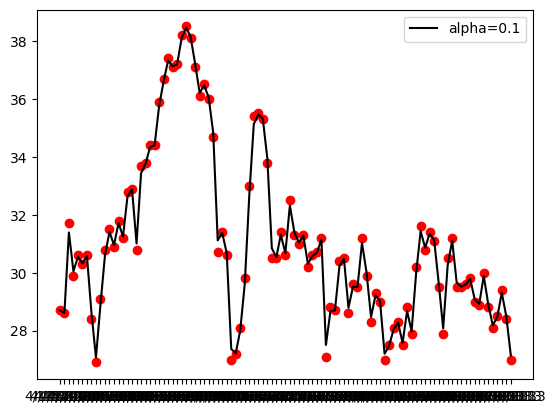

In [103]:
plt.scatter(df['DATE'].iloc[:101], df['temp'].iloc[:101], color='red')
plt.plot(df['DATE'].iloc[:101], x1[:101], color='black', label='alpha=0.1')
plt.legend()
plt.show()

# For b=0.9 more smooth

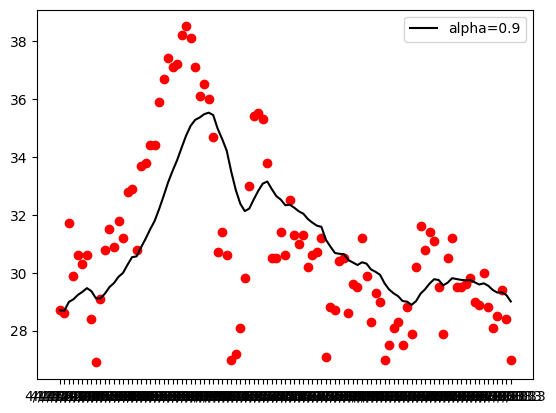

In [104]:
x2 = ewma(y)

plt.scatter(df['DATE'].iloc[:101], df['temp'].iloc[:101], color='red')
plt.plot(df['DATE'].iloc[:101], x2[:101], color='black', label='alpha=0.9')
plt.legend()
plt.show()

## For b=0.5

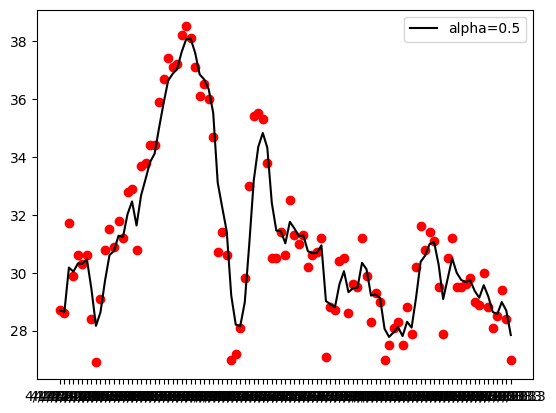

In [105]:
x3 = ewma(y, b=0.5)

plt.scatter(df['DATE'].iloc[:101], df['temp'].iloc[:101], color='red')
plt.plot(df['DATE'].iloc[:101], x3[:101], color='black', label='alpha=0.5')
plt.legend()
plt.show()